In [12]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set(style="whitegrid")

In [13]:
# Load the CPI dataset (make sure your path is correct)
df_cpi = pd.read_csv("CPI_Historic_Values_Zindi_May_23.csv")

# Display first few rows to understand structure
df_cpi.head()

,Month,Category,Value,Percentage Change (From Prior Month)
0,31-05-2023,Headline_CPI,109.6,0.2
1,31-05-2023,Food and non-alcoholic beverages,117.7,0.3
2,31-05-2023,Alcoholic beverages and tobacco,110.6,0.4
3,31-05-2023,Clothing and footwear,104.1,0.4
4,31-05-2023,Housing and utilities,104.6,0.0


In [14]:
# Check number of rows and columns
df_cpi.shape

# Check column names and data types
df_cpi.info()

# Summary statistics
df_cpi.describe()

# View column names clearly
df_cpi.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Month                                 221 non-null    object 
 1   Category                              221 non-null    object 
 2   Value                                 221 non-null    float64
 3   Percentage Change (From Prior Month)  221 non-null    float64
dtypes: float64(2), object(2)
memory usage: 7.0+ KB


Index(['Month', 'Category', 'Value', 'Percentage Change (From Prior Month)'], dtype='object')

In [15]:
# Rename long column name to something easier to use
df_cpi.rename(columns={
    'Percentage Change (From Prior Month)': 'pct_change'
}, inplace=True)

In [16]:
# Convert Month column to datetime format
df_cpi['Month'] = pd.to_datetime(df_cpi['Month'], dayfirst=True)

# Sort values by date (important for time series)
df_cpi = df_cpi.sort_values('Month')

In [17]:
# Check unique CPI categories (e.g., Headline, Food, Transport)
df_cpi['Category'].unique()

array(['Miscellaneous goods and services', 'Headline_CPI',
       'Food and non-alcoholic beverages',
       'Alcoholic beverages and tobacco', 'Clothing and footwear',
       'Housing and utilities', 'Restaurants and hotels ', 'Health',
       'Education', 'Recreation and culture',
       'Household contents and services', 'Transport', 'Communication'],
      dtype=object)

In [18]:
# Pivot the dataset so each CPI category becomes a column
df_wide = df_cpi.pivot(
    index='Month',      # rows = time
    columns='Category', # columns = CPI categories
    values='Value'      # values = CPI values
)

# Reset index to make Month a column again
df_wide = df_wide.reset_index()

# Sort by date again
df_wide = df_wide.sort_values('Month')

# View transformed dataset
df_wide.head()

Category,Month,Alcoholic beverages and tobacco,Clothing and footwear,Communication,Education,Food and non-alcoholic beverages,Headline_CPI,Health,Household contents and services,Housing and utilities,Miscellaneous goods and services,Recreation and culture,Restaurants and hotels,Transport
0,2022-01-31,100.0,100.2,99.8,100.0,100.9,100.2,100.1,100.4,100.0,100.6,100.2,101.2,98.9
1,2022-02-28,100.6,100.3,99.7,100.0,101.8,100.8,103.2,100.4,100.1,101.5,100.3,101.9,100.6
2,2022-03-31,102.8,100.5,99.7,104.4,102.4,101.8,103.7,100.8,100.5,101.9,100.4,103.0,103.7
3,2022-04-30,103.6,100.7,99.6,104.4,103.1,102.4,104.0,101.1,100.5,102.8,100.7,103.3,105.1
4,2022-05-31,104.4,100.9,99.9,104.4,105.3,103.1,104.3,101.8,100.6,102.9,101.0,103.8,105.9


In [19]:
# Check missing values in each column
df_wide.isnull().sum()

Category
Month                               0
Alcoholic beverages and tobacco     0
Clothing and footwear               0
Communication                       0
Education                           0
Food and non-alcoholic beverages    0
Headline_CPI                        0
Health                              0
Household contents and services     0
Housing and utilities               0
Miscellaneous goods and services    0
Recreation and culture              0
Restaurants and hotels              0
Transport                           0
dtype: int64

In [20]:
# Fill missing values using forward fill (common for time series)
df_wide.fillna(method='ffill', inplace=True)

C:\Users\R8885477\AppData\Local\Temp\ipykernel_20732\2594423793.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_wide.fillna(method='ffill', inplace=True)


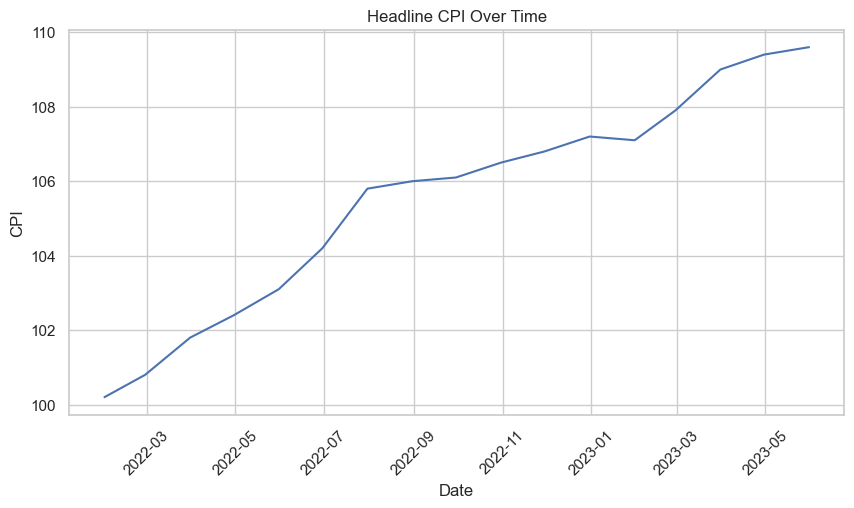

In [22]:
# Plot the main target variable (Headline CPI)
plt.figure(figsize=(10,5))
plt.plot(df_wide['Month'], df_wide['Headline_CPI'])
plt.title("Headline CPI Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.xticks(rotation=45)
plt.show()

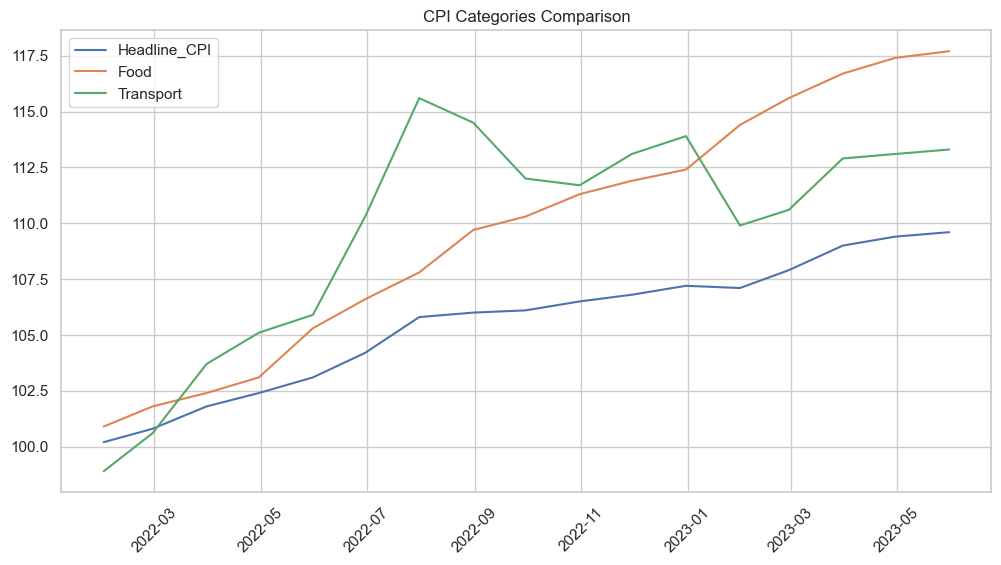

In [28]:
# Plot a few important CPI categories to compare trends
plt.figure(figsize=(12,6))

plt.plot(df_wide['Month'], df_wide['Headline_CPI'], label='Headline_CPI')
plt.plot(df_wide['Month'], df_wide['Food and non-alcoholic beverages'], label='Food')
plt.plot(df_wide['Month'], df_wide['Transport'], label='Transport')

plt.legend()
plt.title("CPI Categories Comparison")
plt.xticks(rotation=45)
plt.show()

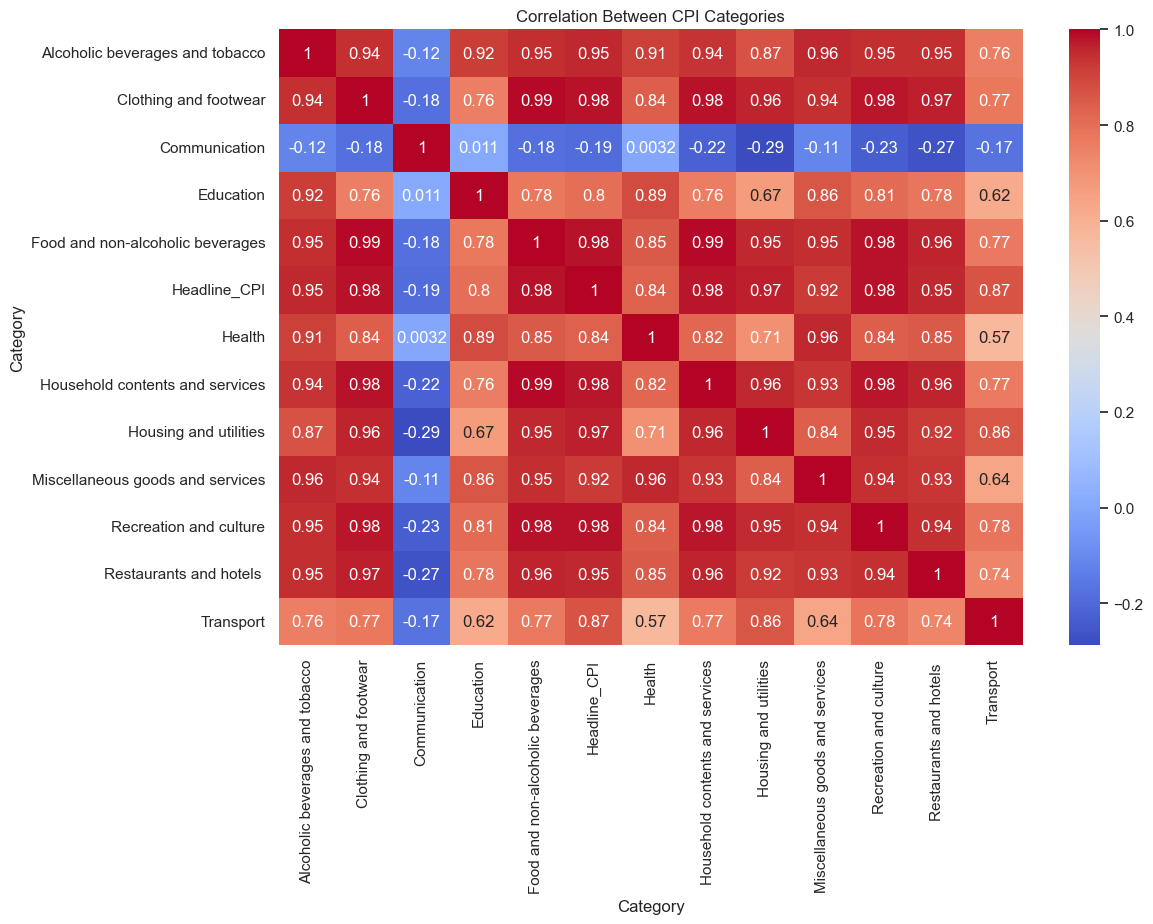

In [29]:
# Compute correlation between all CPI categories
corr = df_wide.drop(columns=['Month']).corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Between CPI Categories")
plt.show()

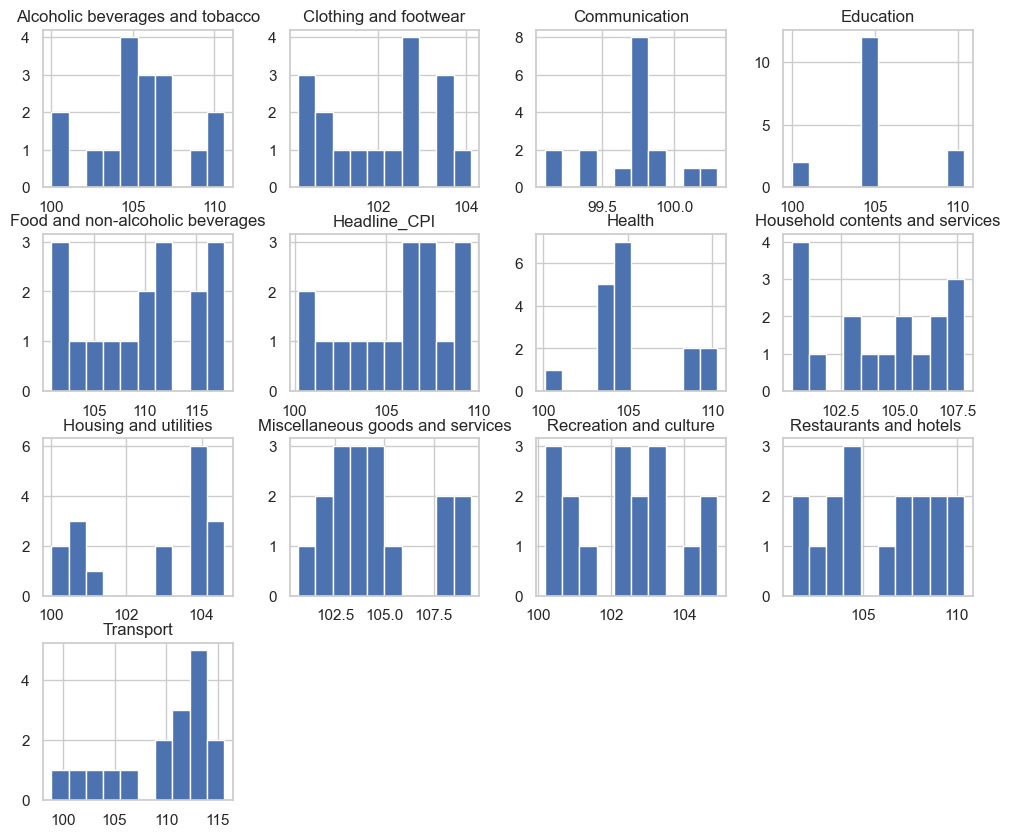

In [30]:
# Plot histograms to understand distributions
df_wide.drop(columns=['Month']).hist(figsize=(12,10))
plt.show()

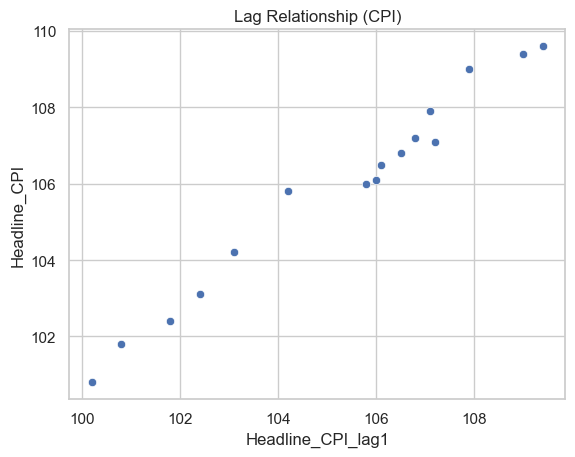

In [32]:
# Create a lag feature (previous month's CPI)
df_wide['Headline_CPI_lag1'] = df_wide['Headline_CPI'].shift(1)

# Plot relationship between lag and current value
sns.scatterplot(
    x=df_wide['Headline_CPI_lag1'],
    y=df_wide['Headline_CPI']
)

plt.title("Lag Relationship (CPI)")
plt.show()

In [34]:
# Save cleaned dataset for later use (Day 2 & 3)
df_wide.to_csv("clean_cpi.csv", index=False)